<a href="https://colab.research.google.com/github/AleximperV/ThucHanhDeepLearning/blob/main/Buoi4/CNNLyThuyet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 495kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.90MB/s]


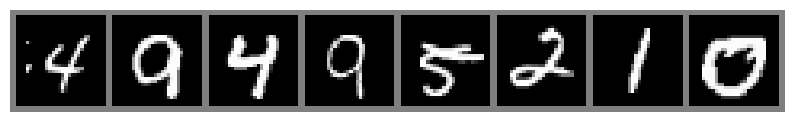

Nhãn tương ứng: 4 9 4 9 5 2 1 0


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. TIỀN XỬ LÝ VÀ TẢI DỮ LIỆU (DATALOADER)
# ==========================================
# Chuyển đổi ma trận pixel thành Tensor và chuẩn hóa giá trị về khoảng [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Tải tập Train và Test trực tiếp từ torchvision
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# ==========================================
# 2. XÂY DỰNG KIẾN TRÚC MẠNG CNN
# ==========================================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Khối trích xuất đặc trưng (Feature Extraction)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Khối phân loại (Classification)
        # Kích thước tensor sau 2 lần MaxPool: 28x28 -> 14x14 -> 7x7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10) # 10 đầu ra tương ứng 10 chữ số

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # Ép phẳng tensor để đưa vào lớp Linear
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN()

# ==========================================
# 3. TRỰC QUAN HÓA DỮ LIỆU ĐẦU VÀO
# ==========================================
def imshow(img):
    img = img / 2 + 0.5  # Un-normalize để đưa về khoảng [0, 1]
    npimg = img.numpy()
    plt.figure(figsize=(10, 4))
    # Sử dụng tông màu sáng, viền biểu đồ tối giản với màu Navy (#1B3A68)
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.gca().spines['top'].set_color('#1B3A68')
    plt.gca().spines['bottom'].set_color('#1B3A68')
    plt.gca().spines['left'].set_color('#1B3A68')
    plt.gca().spines['right'].set_color('#1B3A68')
    plt.axis('off')
    plt.show()

# Lấy thử một batch dữ liệu và hiển thị
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Hiển thị 8 ảnh đầu tiên trong batch
imshow(torchvision.utils.make_grid(images[:8]))
print('Nhãn tương ứng:', ' '.join(f'{labels[j].item()}' for j in range(8)))

Kích thước dữ liệu gốc: (60000, 784) (60000,) (10000, 784) (10000,)

Cấu trúc mô hình ban đầu:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)


Bắt đầu huấn luyện...
Epoch 1/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9153 - loss: 0.2921 - val_accuracy: 0.9783 - val_loss: 0.0803
Epoch 2/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9751 - loss: 0.0804 - val_accuracy: 0.9833 - val_loss: 0.0556
Epoch 3/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9823 - loss: 0.0584 - val_accuracy: 0.9863 - val_loss: 0.0491
Epoch 4/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9854 - loss: 0.0476 - val_accuracy: 0.9888 - val_loss: 0.0446
Epoch 5/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9878 - loss: 0.0395 - val_accuracy: 0.9883 - val_loss: 0.0449
Epoch 6/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9895 - loss: 0.0343 - val_accuracy: 0.9888 - val_loss: 0.0381
Epoch 7/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9905 - loss: 0.0301 - val_accuracy: 0.9905 - val_loss: 0.0328
Epoch 8/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9920 - loss: 0

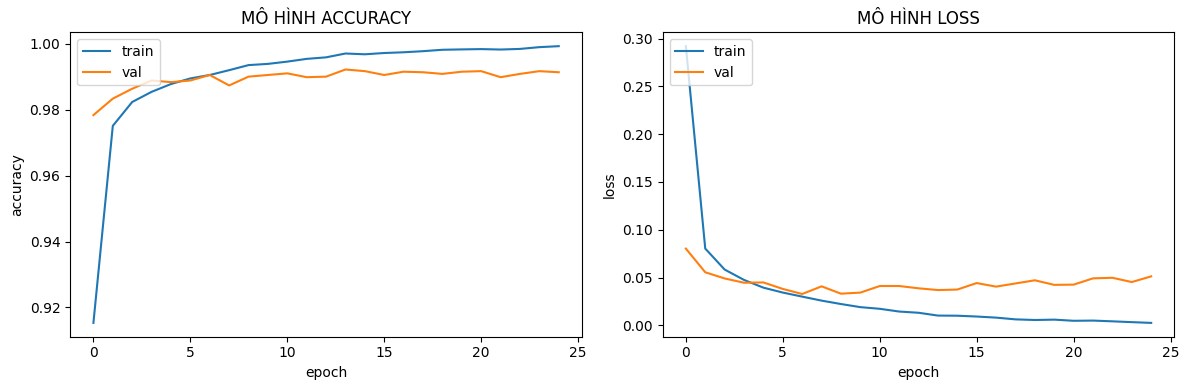


Đánh giá trên tập test...
313/313 - 2s - 5ms/step - accuracy: 0.9880 - loss: 0.0489

--- KẾT QUẢ TRÊN TẬP TEST ---
Test loss: 0.0489116869866848
Test accuracy: 0.9879999756813049

Tiến hành dự báo thử nghiệm trên ảnh đầu tiên của tập test...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
Xác suất dự báo cho từng lớp:
 [[8.3970251e-20 3.7017103e-17 1.6341400e-09 1.6300465e-09 2.2790841e-20
  6.8961940e-14 2.5066777e-27 1.0000000e+00 7.9963088e-14 1.2462241e-10]]
Nhãn dự báo: 7 | Nhãn thực tế: 7


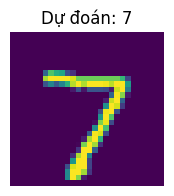


Đang lưu tham số mô hình vào file 'cnn.weights.h5'...

--- TIẾN HÀNH KHỞI TẠO LẠI MÔ HÌNH MỚI TINH ĐỂ THỬ TÍNH NĂNG NẠP ---
Đang nạp lại bộ trọng số (weights) từ 'cnn.weights.h5' vào mô hình mới...
Thử nghiệm dự báo ảnh thứ 2 (chỉ số index 1) bằng mô hình vừa nạp lại...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
Nhãn dự báo từ mô hình vừa phục hồi: 2 | Nhãn thực tế: 2


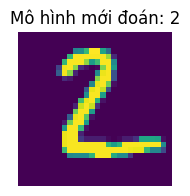

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

# --- BƯỚC 1: ĐỌC DỮ LIỆU ---
mnist_train = '/content/drive/MyDrive/mnist_train.csv'
mnist_test = '/content/drive/MyDrive/mnist_test.csv'

# Đoạn code dự phòng nếu bạn chưa mount Drive hoặc sai đường dẫn
import os
if not os.path.exists(mnist_train):
    print("Không tìm thấy file trong Drive, chuyển sang dùng sample_data mặc định...")
    mnist_train = '/content/sample_data/mnist_train_small.csv'
    mnist_test = '/content/sample_data/mnist_test.csv'

df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

# Tách features (X) và nhãn (y)
X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]
X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]

print("Kích thước dữ liệu gốc:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# --- BƯỚC 2: TIỀN XỬ LÝ DỮ LIỆU ---
num_classes = 10
input_shape = (28, 28, 1)

# Chuẩn hóa giá trị pixel
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Reshape dữ liệu về dạng ảnh 2D
X_train = X_train.to_numpy().reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.to_numpy().reshape(X_test.shape[0], 28, 28, 1)

# Chuyển nhãn sang one-hot encoding
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

# --- BƯỚC 3: XÂY DỰNG MÔ HÌNH CNN ---
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))

print("\nCấu trúc mô hình ban đầu:")
model.summary()

# --- BƯỚC 4: HUẤN LUYỆN VÀ ĐÁNH GIÁ TRÊN TẬP VAL ---
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\nBắt đầu huấn luyện...")
model_fit = model.fit(X_train, y_train_cat, batch_size=128, epochs=25, validation_split=0.1, verbose=1)

# --- BƯỚC 5: VẼ ĐỒ THỊ ĐÁNH GIÁ (LOSS & ACCURACY) ---
plt.figure(figsize=(12, 4))

# Đồ thị Accuracy
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('MÔ HÌNH ACCURACY')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

# Đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('MÔ HÌNH LOSS')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.tight_layout()
plt.show()

# --- BƯỚC 6: ĐÁNH GIÁ TRÊN TẬP TEST ---
print("\nĐánh giá trên tập test...")
score = model.evaluate(X_test, y_test_cat, verbose=2)
print('\n--- KẾT QUẢ TRÊN TẬP TEST ---')
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# --- BƯỚC 7: DỰ BÁO NHÃN CHO 1 ẢNH BẤT KỲ ---
print("\nTiến hành dự báo thử nghiệm trên ảnh đầu tiên của tập test...")
predict_0 = model.predict(X_test[:1])
predicted_label = np.argmax(predict_0)
actual_label = int(y_test.iloc[0])

print(f"Xác suất dự báo cho từng lớp:\n {predict_0}")
print(f"Nhãn dự báo: {predicted_label} | Nhãn thực tế: {actual_label}")

# Trực quan hóa ảnh được dự báo
plt.figure(figsize=(2,2))
plt.imshow(X_test[0].reshape(28, 28))
plt.title(f"Dự đoán: {predicted_label}")
plt.axis('off')
plt.show()

# --- BƯỚC 8: LƯU THAM SỐ MÔ HÌNH (Đã sửa đuôi file cho Keras 3) ---
print("\nĐang lưu tham số mô hình vào file 'cnn.weights.h5'...")
model.save_weights('/content/drive/MyDrive/cnn.weights.h5')

# --- BƯỚC 9: KHỞI TẠO LẠI VÀ NẠP LẠI THAM SỐ ---
print("\n--- TIẾN HÀNH KHỞI TẠO LẠI MÔ HÌNH MỚI TINH ĐỂ THỬ TÍNH NĂNG NẠP ---")
new_model = Sequential()
new_model.add(Input(shape=input_shape))
new_model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
new_model.add(MaxPool2D(pool_size=(2,2)))
new_model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
new_model.add(MaxPool2D(pool_size=(2,2)))
new_model.add(Flatten())
new_model.add(Dense(units=10, activation='softmax'))

# Nạp lại tham số đã lưu trước đó (Đã sửa đuôi file cho Keras 3)
print("Đang nạp lại bộ trọng số (weights) từ 'cnn.weights.h5' vào mô hình mới...")
new_model.load_weights('/content/drive/MyDrive/cnn.weights.h5')

# Dự báo thử nghiệm bằng mô hình mới nạp để chứng minh nó hoạt động
print("Thử nghiệm dự báo ảnh thứ 2 (chỉ số index 1) bằng mô hình vừa nạp lại...")
predict_1 = new_model.predict(X_test[1:2])
predicted_label_new = np.argmax(predict_1)
actual_label_new = int(y_test.iloc[1])

print(f"Nhãn dự báo từ mô hình vừa phục hồi: {predicted_label_new} | Nhãn thực tế: {actual_label_new}")

# Trực quan hóa ảnh thứ 2
plt.figure(figsize=(2,2))
plt.imshow(X_test[1].reshape(28, 28))
plt.title(f"Mô hình mới đoán: {predicted_label_new}")
plt.axis('off')
plt.show()


--- TIẾN HÀNH KHỞI TẠO LẠI MÔ HÌNH MỚI TINH ĐỂ THỬ TÍNH NĂNG NẠP ---
Đang nạp lại bộ trọng số (weights) từ 'cnn.weights.h5' vào mô hình mới...
Thử nghiệm dự báo ảnh thứ 2 (chỉ số index 1) bằng mô hình vừa nạp lại...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
Ảnh index: 3631
Nhãn dự báo: 5 | Nhãn thực tế: 5


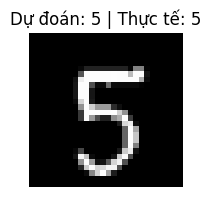

In [ ]:
import keras
from keras.models import Sequential
# --- BƯỚC 9: KHỞI TẠO LẠI VÀ NẠP LẠI THAM SỐ ---
print("\n--- TIẾN HÀNH KHỞI TẠO LẠI MÔ HÌNH MỚI TINH ĐỂ THỬ TÍNH NĂNG NẠP ---")
new_model = Sequential()
new_model.add(Input(shape=input_shape))
new_model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
new_model.add(MaxPool2D(pool_size=(2,2)))
new_model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
new_model.add(MaxPool2D(pool_size=(2,2)))
new_model.add(Flatten())
new_model.add(Dense(units=10, activation='softmax'))
# Nạp lại tham số đã lưu trước đó (Đã sửa đuôi file cho Keras 3)
print("Đang nạp lại bộ trọng số (weights) từ 'cnn.weights.h5' vào mô hình mới...")
new_model.load_weights('/content/drive/MyDrive/cnn.weights.h5')

# Dự báo thử nghiệm bằng mô hình mới nạp để chứng minh nó hoạt động
print("Thử nghiệm dự báo ảnh thứ 2 (chỉ số index 1) bằng mô hình vừa nạp lại...")
index = np.random.randint(0, len(X_test))

predict_1 = new_model.predict(X_test[index:index+1])
predicted_label_new = np.argmax(predict_1)
actual_label_new = int(y_test.iloc[index])

print(f"Ảnh index: {index}")
print(f"Nhãn dự báo: {predicted_label_new} | Nhãn thực tế: {actual_label_new}")

plt.figure(figsize=(2,2))
plt.imshow(X_test[index].reshape(28, 28), cmap='gray')
plt.title(f"Dự đoán: {predicted_label_new} | Thực tế: {actual_label_new}")
plt.axis('off')
plt.show()